# Implémentation de l'algorithme K-Nearest Neighbors (KNN) - Dataset Wine

Ce notebook illustre le fonctionnement du KNN sur un problème de classification multi-classe. 
Nous utilisons le jeu de données **Wine**, où l'objectif est de prédire l'origine d'un vin (Classe 0, 1 ou 2) en fonction de ses analyses chimiques.

Au programme :
1. Préparation et normalisation des données (crucial ici car les échelles varient énormément).
2. Recherche graphique du $K$ optimal (compromis Biais-Variance).
3. Évaluation via une matrice de confusion $3 \times 3$.

In [2]:
# Importations des modules nécessaires pour la manipulation des données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importations des modules Scikit-Learn pour le Machine Learning
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
print("Bibliothèques chargées avec succès pour le dataset Wine !")

Bibliothèques chargées avec succès pour le dataset Wine !


## Étape 1 : Chargement et Préparation des Données

Ici, la normalisation avec **StandardScaler** est indispensable. Sans elle, la variable "Proline" (qui a des valeurs supérieures à 1000) fausserait complètement le calcul des distances géométriques par rapport à la variable "Alcool" (valeurs autour de 13).

In [3]:
# 1. Chargement du dataset (3 classes de vin)
data = load_wine()
X = data.data  # Caractéristiques chimiques (Alcool, Magnésium, Proline, etc.)
y = data.target  # Les étiquettes (0, 1, ou 2 pour les 3 types de vins)

# 2. Séparation du dataset : 75% entraînement, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 3. Initialisation du scaler pour normaliser les données
scaler = StandardScaler()

# 4. Ajustement et transformation du train set
X_train_scaled = scaler.fit_transform(X_train)

# 5. Transformation du test set (avec la même logique)
X_test_scaled = scaler.transform(X_test)

print(f"Features détectées : {data.feature_names}")
print(f"Classes cibles : {data.target_names}")
print(f"Taille du jeu d'entraînement : {X_train_scaled.shape}")

Features détectées : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes cibles : ['class_0' 'class_1' 'class_2']
Taille du jeu d'entraînement : (133, 13)


## Étape 2 : Analyse du comportement de K (Sur et Sous-apprentissage)

Nous testons les valeurs de $K$ allant de 1 à 25. 
Comme le KNN fonctionne par vote majoritaire, le fait d'avoir 3 classes signifie qu'un choix de $K$ pair ou impair peut fonctionner, mais on préfère analyser toute la courbe pour repérer visuellement :
* Le **Sur-apprentissage** (à gauche, $K=1$) : Le modèle connaît le train par cœur mais généralise moins bien.
* Le **Sous-apprentissage** (à droite, $K$ trop grand) : Le modèle devient trop simpliste.

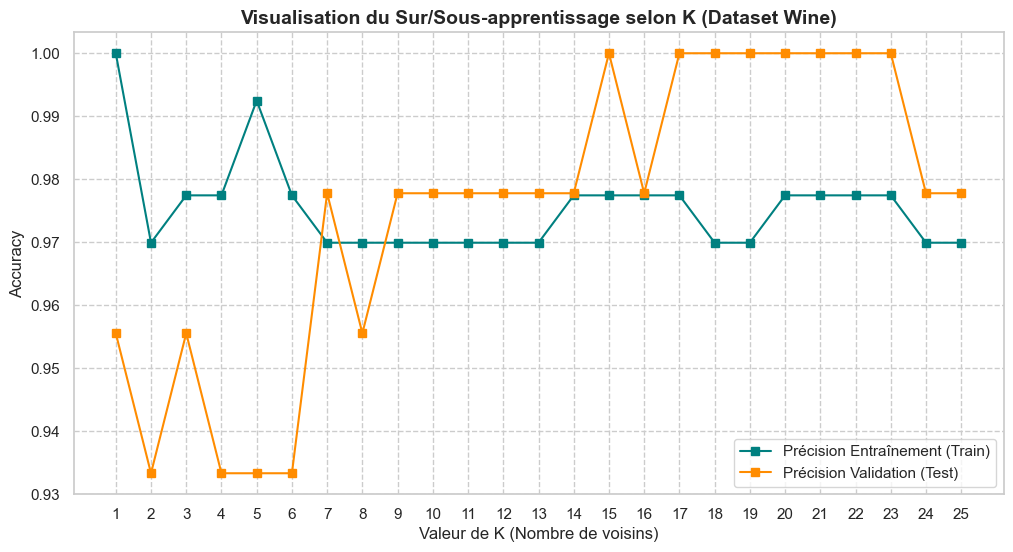

In [4]:
# Listes pour stocker les scores d'accuracy
k_values = list(range(1, 26))
train_accuracies = []
test_accuracies = []

# Expérimentation
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Évaluation Train
    y_train_pred = knn.predict(X_train_scaled)
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    
    # Évaluation Test
    y_test_pred = knn.predict(X_test_scaled)
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

# ---- COMPORTEMENT GRAPHIQUE ----
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_accuracies, label='Précision Entraînement (Train)', color='teal', marker='s')
plt.plot(k_values, test_accuracies, label='Précision Validation (Test)', color='darkorange', marker='s')

plt.title("Visualisation du Sur/Sous-apprentissage selon K (Dataset Wine)", fontsize=14, fontweight='bold')
plt.xlabel("Valeur de K (Nombre de voisins)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

## Étape 3 : Entraînement du modèle final

Sur ce dataset précis, le KNN performe généralement de manière exceptionnelle dès que les données sont scalées. Choisissons un $K$ intermédiaire stable (par exemple **$K = 5$** ou **$K = 7$**) qui évite le bruit tout en gardant une excellente précision locale.

In [5]:
# Choix du K optimal d'après notre graphique
k_optimal = 5

# Création et entraînement du modèle final
final_knn = KNeighborsClassifier(n_neighbors=k_optimal)
final_knn.fit(X_train_scaled, y_train)

# Prédiction sur les données de test
final_preds = final_knn.predict(X_test_scaled)

# Calcul du score
final_accuracy = accuracy_score(y_test, final_preds)
print(f"🎯 Précision globale (Accuracy) avec K={k_optimal} : {final_accuracy:.2%}")

🎯 Précision globale (Accuracy) avec K=5 : 93.33%


## Étape 4 : Matrice de Confusion Multi-classe

Puisque nous avons 3 types de vins, la matrice de confusion sera un tableau de taille $3 \times 3$. 
Elle permet de voir si l'algorithme "aveugle" a tendance à confondre le Vin de la classe 1 avec celui de la classe 2 lors de son vote local.

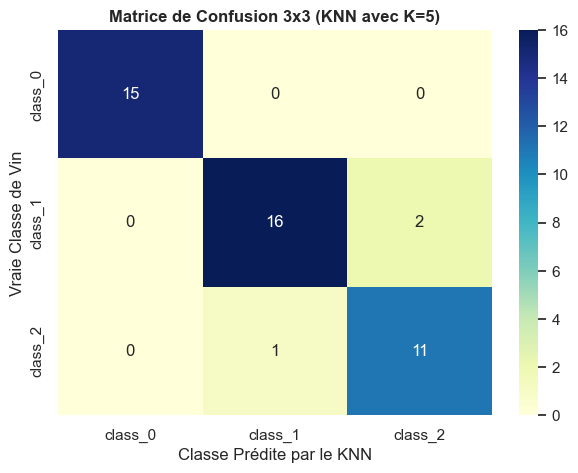


=== RAPPORT DE CLASSIFICATION MULTI-CLASSE ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.94      0.89      0.91        18
     class_2       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



In [6]:
# Calcul de la matrice de confusion 3x3
cm = confusion_matrix(y_test, final_preds)

# Affichage graphique personnalisé
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=data.target_names, 
            yticklabels=data.target_names)

plt.title(f"Matrice de Confusion 3x3 (KNN avec K={k_optimal})", fontsize=12, fontweight='bold')
plt.ylabel("Vraie Classe de Vin")
plt.xlabel("Classe Prédite par le KNN")
plt.show()

# Rapport détaillé (Precision, Recall par classe)
print("\n=== RAPPORT DE CLASSIFICATION MULTI-CLASSE ===")
print(classification_report(y_test, final_preds, target_names=data.target_names))